In [1]:
print('Radha!')

Radha!


In [2]:
from typing import TypedDict
from langgraph.graph import  StateGraph, START, END

In [3]:
class SupportState(TypedDict):
    ticket: str
    category: str
    priority: str
    customer_name: str
    response: str

In [4]:
def classify_issue(state: SupportState):
    ticket = state["ticket"].lower()

    if "payment" in ticket or "refund" in ticket:
        return {"category": "billing"}

    if "login" in ticket or "password" in ticket:
        return {"category": "account"}

    return {"category": "general"}

In [5]:
def detect_priority(state: SupportState):

    if "urgent" in state["ticket"].lower():
        return {"priority": "high"}

    return {"priority": "normal"}

In [6]:
def extract_details(state: SupportState):

    # simplified for learning
    return {
        "customer_name": "Rahul"
    }

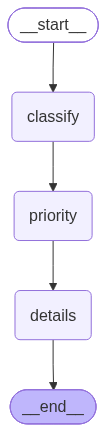

In [7]:
analysis_builder = StateGraph(SupportState)

analysis_builder.add_node("classify", classify_issue)
analysis_builder.add_node("priority", detect_priority)
analysis_builder.add_node("details", extract_details)

analysis_builder.add_edge(START, "classify")
analysis_builder.add_edge("classify", "priority")
analysis_builder.add_edge("priority", "details")
analysis_builder.add_edge("details", END)

analysis_subgraph = analysis_builder.compile()
analysis_subgraph

In [8]:
def generate_response(state: SupportState):

    return {
        "response": (
            f"Hello {state['customer_name']}, "
            f"your {state['category']} issue has "
            f"{state['priority']} priority."
        )
    }

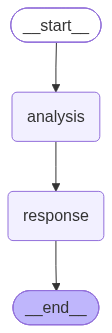

In [9]:
parent_builder = StateGraph(SupportState)

parent_builder.add_node(
    "analysis",
    analysis_subgraph
)

parent_builder.add_node(
    "response",
    generate_response
)

parent_builder.add_edge(START, "analysis")
parent_builder.add_edge("analysis", "response")
parent_builder.add_edge("response", END)

support_graph = parent_builder.compile()

support_graph

In [15]:
result = support_graph.invoke({
    "ticket": "Urgent! My payment failed and I need a refund.",
    "category": "",
    "priority": "",
    "customer_name": "",
    "response": ""
})
result

{'ticket': 'Urgent! My payment failed and I need a refund.',
 'category': 'billing',
 'priority': 'high',
 'customer_name': 'Rahul',
 'response': 'Hello Rahul, your billing issue has high priority.'}

In [16]:
print("Category:", result["category"])
print("Priority:", result["priority"])
print("Customer:", result["customer_name"])
print("Response:", result["response"])

Category: billing
Priority: high
Customer: Rahul
Response: Hello Rahul, your billing issue has high priority.


In [17]:
result = support_graph.invoke({
    "ticket": "I forgot my password and cannot login to my account.",
    "category": "",
    "priority": "",
    "customer_name": "",
    "response": ""
})

result

{'ticket': 'I forgot my password and cannot login to my account.',
 'category': 'account',
 'priority': 'normal',
 'customer_name': 'Rahul',
 'response': 'Hello Rahul, your account issue has normal priority.'}

In [18]:
print("Category:", result["category"])
print("Priority:", result["priority"])
print("Customer:", result["customer_name"])
print("Response:", result["response"])

Category: account
Priority: normal
Customer: Rahul
Response: Hello Rahul, your account issue has normal priority.


In [13]:
result = support_graph.invoke({
    "ticket": "I want to know more about your services.",
    "category": "",
    "priority": "",
    "customer_name": "",
    "response": ""
})
result

{'ticket': 'I want to know more about your services.',
 'category': 'general',
 'priority': 'normal',
 'customer_name': 'Rahul',
 'response': 'Hello Rahul, your general issue has normal priority.'}

In [14]:
print("Category:", result["category"])
print("Priority:", result["priority"])
print("Customer:", result["customer_name"])
print("Response:", result["response"])

Category: general
Priority: normal
Customer: Rahul
Response: Hello Rahul, your general issue has normal priority.
